# Figure 3 — Flow-type decomposition (within / inflow / outflow)

**Target**: npj Urban Sustainability submission (Helene + Milton mobility paper).

**Three panels, generated as separate files** for external composition (Illustrator / Inkscape / Affinity / PowerPoint):

- **(a)** Paired bars of within vs. inflow recovery time across the 6 categories, one subpanel per hurricane.
- **(b)** Outflow % deviation from baseline across days-from-landing for each category, with the **−3 d → +6 d** evacuation window shaded and peak surge marked. One subpanel per hurricane.
- **(c)** Worked example: relative deviation of all three flows (within, inflow, outflow) for one illustrative category on a single time axis.

**Data sources** (all pre-computed — *no analysis re-run*):
- Recovery / surge metrics — `results/regional_level/regional_metrics_summary.csv`
- Regional baselines (per flow × category) — `results/regional_level/{helene,milton}/baseline_{flow}_{Category}.csv`

**Outputs** (vector PDF + 300 dpi PNG per panel) in `results/npj_figures/`:
- `figure3a_recovery_paired.{pdf,png}`
- `figure3b_outflow_surge.{pdf,png}`
- `figure3c_three_flows.{pdf,png}`

**Scope note**: Utilities category is excluded per submission scope. Outflow has no `recovery_days` (the trend-based recovery is designed for negative troughs), so panel (a) compares within vs. inflow only; outflow is summarised by surge magnitude in panel (b).

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# npj Urban Sustainability print-ready formatting (matches figure 1)
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [2]:
# ── Project path resolution (walk up to the directory holding results/) ──
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'regional_level' / 'regional_metrics_summary.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(
        f'Could not locate project root containing {sentinel} (started from {start}).'
    )

NOTEBOOK_DIR = pathlib.Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
RESULTS = PROJECT_ROOT / 'results'
REGIONAL = RESULTS / 'regional_level'
METRICS_CSV = REGIONAL / 'regional_metrics_summary.csv'

OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'METRICS_CSV  : exists={METRICS_CSV.exists()}')
print(f'OUT_DIR      : {OUT_DIR}')

PROJECT_ROOT : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
METRICS_CSV  : exists=True
OUT_DIR      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures


In [3]:
# ── Configuration ──
HURRICANES = {
    'helene': {'label': 'Helene', 'landing': pd.Timestamp('2024-09-26'), 'color': '#1f77b4'},
    'milton': {'label': 'Milton', 'landing': pd.Timestamp('2024-10-09'), 'color': '#d62728'},
}

# 6 mobility categories (Utilities excluded per npj scope)
CATEGORIES = [
    'Travel',
    'Work & Professional',
    'Health',
    'Education',
    'Retail & Leisure',
    'Urban Government',
]

# Okabe-Ito colorblind-safe palette (matches figure 1)
CATEGORY_COLORS = {
    'Travel'             : '#0072B2',
    'Work & Professional': '#E69F00',
    'Health'             : '#009E73',
    'Education'          : '#CC79A7',
    'Retail & Leisure'   : '#56B4E9',
    'Urban Government'   : '#D55E00',
}

# Flow-type palette (matches schematic in figure 1b)
FLOW_COLORS = {
    'within' : '#2b8a3e',
    'inflow' : '#1971c2',
    'outflow': '#c92a2a',
}
FLOW_LABELS = {'within': 'Within', 'inflow': 'Inflow', 'outflow': 'Outflow'}

# Evacuation surge window: [-3, +6] days from landing
SURGE_WINDOW = (-3, 6)

# Worked example for panel (c) — change to swap the example
EXAMPLE = {
    'hurricane': 'milton',
    'category':  'Retail & Leisure',
}

def category_to_filename(cat: str) -> str:
    return cat.replace(' & ', '_and_').replace(' ', '_')

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved \u2192 {pdf_path}')
    print(f'  saved \u2192 {png_path}')

# Load the precomputed regional metrics summary once
METRICS = pd.read_csv(METRICS_CSV)
METRICS = METRICS[METRICS['category'].isin(CATEGORIES)].copy()
print(f'Loaded metrics rows: {len(METRICS)} (after Utilities exclusion)')
METRICS.head()

Loaded metrics rows: 36 (after Utilities exclusion)


,hurricane,flow_type,category,largest_drop,drop_date,largest_increase,increase_date,recovery_days,recovery_date,trough_date,slope_pct_per_day,total_disruption
0,milton,within,Travel,-48.623165,2024-10-10,15.278041,2024-10-07,4.826926,2024-10-13 19:50:46.401452813,2024-10-10,739.009566,234.700414
1,milton,within,Work & Professional,-37.233281,2024-10-09,16.108812,2024-10-07,4.788430,2024-10-13 18:55:20.378426848,2024-10-10,583.040727,178.288970
2,milton,within,Health,-25.112259,2024-10-10,21.308645,2024-10-06,4.549102,2024-10-13 13:10:42.393681304,2024-10-10,553.499832,114.238223
3,milton,within,Education,-34.954414,2024-10-11,10.600196,2024-10-06,6.310886,2024-10-15 07:27:40.555063889,2024-10-10,553.584304,220.593323
4,milton,within,Retail & Leisure,-33.086794,2024-10-10,13.453612,2024-10-06,5.157755,2024-10-14 03:47:10.035455438,2024-10-10,571.956247,170.653581


In [4]:
# ── Helper: load a regional baseline CSV and return % deviation series ──
def load_relative_deviation(hkey: str, flow: str, category: str) -> pd.DataFrame:
    """Return a DataFrame indexed by date with columns: y_true, y_pred, rel_dev (%).
    Uses the pre-computed SARIMAX baseline CSV — no fitting performed here.
    """
    path = REGIONAL / hkey / f'baseline_{flow}_{category_to_filename(category)}.csv'
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df['rel_dev'] = (df['y_true'] - df['y_pred']) / df['y_pred'] * 100.0
    return df

# Sanity check on the loader
test = load_relative_deviation('milton', 'outflow', 'Retail & Leisure')
print(test.head(3))
print(f'Range: {test.index.min().date()} \u2192 {test.index.max().date()}  ({len(test)} days)')

                  y_true        y_pred      ci_lower      ci_upper   rel_dev
2024-10-03  1.930953e+06  2.022356e+06  1.830096e+06  2.234813e+06 -4.519613
2024-10-04  2.281067e+06  2.374380e+06  2.088698e+06  2.699135e+06 -3.929990
2024-10-05  2.481879e+06  2.522005e+06  2.184733e+06  2.911344e+06 -1.591059
Range: 2024-10-03 → 2024-10-31  (29 days)


## Panel (a) — Within vs. inflow recovery time across the 6 categories

Paired bars (Within green / Inflow blue) per category, with one subpanel per hurricane. Values come straight from `regional_metrics_summary.csv` (`recovery_days` column). Outflow has no recovery metric in this framework (the trend-based estimator is defined only for negative troughs, and Milton's outflow shows a positive surge), so it is shown in panel (b) instead.

Saves `figure3a_recovery_paired.{pdf,png}`.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure3a_recovery_paired.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure3a_recovery_paired.png


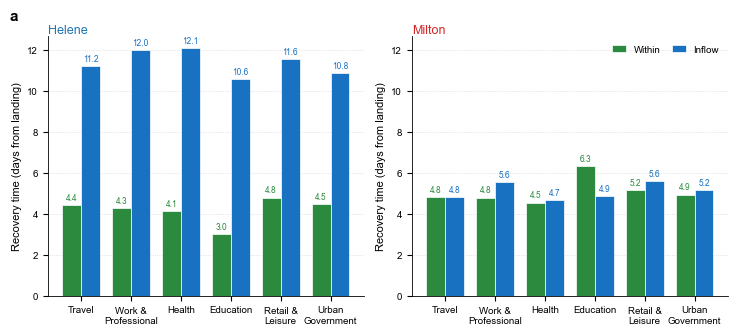

In [5]:
def panel_a_recovery(axes):
    """Two axes, one per hurricane; grouped bars (within / inflow) per category."""
    cats = CATEGORIES
    n = len(cats)
    x = np.arange(n)
    bar_w = 0.38

    # Two-line labels so the longer category names don't collide
    def _wrap(c):
        if ' & ' in c:
            return c.replace(' & ', ' &\n')
        parts = c.split(' ', 1)
        return '\n'.join(parts) if len(parts) == 2 else c

    for ax, hkey in zip(axes, HURRICANES):
        sub = METRICS[(METRICS['hurricane'] == hkey)
                      & (METRICS['flow_type'].isin(['within', 'inflow']))]
        pivot = (sub.pivot_table(index='category', columns='flow_type',
                                  values='recovery_days', aggfunc='first')
                    .reindex(cats))

        ax.bar(x - bar_w / 2, pivot['within'].values, width=bar_w,
               color=FLOW_COLORS['within'], edgecolor='white', linewidth=0.5,
               label=FLOW_LABELS['within'])
        ax.bar(x + bar_w / 2, pivot['inflow'].values, width=bar_w,
               color=FLOW_COLORS['inflow'], edgecolor='white', linewidth=0.5,
               label=FLOW_LABELS['inflow'])

        for xi, (w_val, i_val) in enumerate(zip(pivot['within'].values, pivot['inflow'].values)):
            if pd.notna(w_val):
                ax.text(xi - bar_w / 2, w_val + 0.15, f'{w_val:.1f}',
                        ha='center', va='bottom', fontsize=6, color=FLOW_COLORS['within'])
            if pd.notna(i_val):
                ax.text(xi + bar_w / 2, i_val + 0.15, f'{i_val:.1f}',
                        ha='center', va='bottom', fontsize=6, color=FLOW_COLORS['inflow'])

        ax.set_xticks(x)
        ax.set_xticklabels([_wrap(c) for c in cats], rotation=0, ha='center')
        ax.set_ylabel('Recovery time (days from landing)')
        ax.set_title(HURRICANES[hkey]['label'], loc='left',
                     fontsize=9, color=HURRICANES[hkey]['color'], pad=2)
        ax.grid(axis='y', linestyle=':', color='#bbbbbb', linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)

    ymax = max(a.get_ylim()[1] for a in axes)
    for a in axes:
        a.set_ylim(0, ymax)

    axes[-1].legend(loc='upper right', frameon=False, fontsize=7, ncol=2,
                    handlelength=1.4, columnspacing=1.2)

    axes[0].text(-0.12, 1.05, 'a', transform=axes[0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_a, axes_a = plt.subplots(1, 2, figsize=(7.4, 3.4), sharey=False)
panel_a_recovery(axes_a)
fig_a.tight_layout()
save_panel(fig_a, 'figure3a_recovery_paired')
plt.show()

## Panel (b) — Outflow surge per category (evacuation window)

For each hurricane, the outflow relative-deviation curve is computed from the cached SARIMAX baseline CSV (`(y_true − y_pred) / y_pred × 100`) for the 6 categories. The **−3 d → +6 d** window relative to landing is shaded — this is the search window used to extract `largest_increase` in the metrics summary. Peak markers are drawn at the largest_increase date for each category.

Saves `figure3b_outflow_surge.{pdf,png}`.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure3b_outflow_surge.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure3b_outflow_surge.png


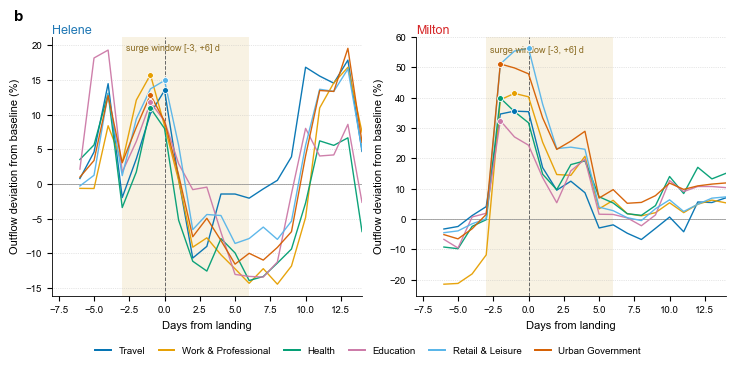

In [6]:
def panel_b_outflow(axes):
    """Two axes (one per hurricane); outflow % deviation vs. days-from-landing."""
    for ax, hkey in zip(axes, HURRICANES):
        landing = HURRICANES[hkey]['landing']

        for cat in CATEGORIES:
            df = load_relative_deviation(hkey, 'outflow', cat)
            dfd = df.copy()
            dfd['days_from_landing'] = (dfd.index - landing).days
            dfd = dfd[(dfd['days_from_landing'] >= -8) & (dfd['days_from_landing'] <= 14)]
            ax.plot(dfd['days_from_landing'], dfd['rel_dev'],
                    color=CATEGORY_COLORS[cat], linewidth=1.0, label=cat, alpha=0.95)

            row = METRICS[(METRICS['hurricane'] == hkey)
                          & (METRICS['flow_type'] == 'outflow')
                          & (METRICS['category']  == cat)]
            if not row.empty and pd.notna(row['increase_date'].iloc[0]):
                inc_date = pd.to_datetime(row['increase_date'].iloc[0])
                inc_pct  = float(row['largest_increase'].iloc[0])
                d_off    = (inc_date - landing).days
                if SURGE_WINDOW[0] <= d_off <= SURGE_WINDOW[1]:
                    ax.scatter([d_off], [inc_pct], s=18,
                               color=CATEGORY_COLORS[cat],
                               edgecolor='white', linewidth=0.6, zorder=5)

        ax.axvspan(SURGE_WINDOW[0], SURGE_WINDOW[1],
                   facecolor='#f0e3c2', alpha=0.45, zorder=0)
        ax.axvline(0, color='#666666', linestyle='--', linewidth=0.7, zorder=1)
        ax.axhline(0, color='#888888', linestyle='-', linewidth=0.5, zorder=1)

        ax.set_xlabel('Days from landing')
        ax.set_ylabel('Outflow deviation from baseline (%)')
        ax.set_title(HURRICANES[hkey]['label'], loc='left',
                     fontsize=9, color=HURRICANES[hkey]['color'], pad=2)
        ax.grid(axis='y', linestyle=':', color='#bbbbbb', linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)
        ax.set_xlim(-8, 14)

        # Window annotation pinned to the upper edge of the shaded band
        ax.text(SURGE_WINDOW[0] + 0.3, ax.get_ylim()[1] * 0.95,
                f'surge window [{SURGE_WINDOW[0]:+d}, {SURGE_WINDOW[1]:+d}] d',
                ha='left', va='top', fontsize=6.5, color='#8a6b22')

    # Shared category legend below both axes — keeps the plot area clean
    handles = [Line2D([0], [0], color=CATEGORY_COLORS[c], linewidth=1.4, label=c)
               for c in CATEGORIES]
    axes[0].figure.legend(handles=handles, loc='lower center', frameon=False,
                          fontsize=7, ncol=6, bbox_to_anchor=(0.5, -0.02),
                          handlelength=1.6, columnspacing=1.4)

    axes[0].text(-0.12, 1.05, 'b', transform=axes[0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_b, axes_b = plt.subplots(1, 2, figsize=(7.4, 3.6), sharey=False)
panel_b_outflow(axes_b)
fig_b.tight_layout(rect=[0, 0.04, 1, 1])
save_panel(fig_b, 'figure3b_outflow_surge')
plt.show()

## Panel (c) — Three flows on one axis for one illustrative category

Within / inflow / outflow relative deviations on a common time axis for one category and hurricane (configured via `EXAMPLE`). Each line is `(y_true − y_pred) / y_pred × 100` from the cached baseline CSV. Trough markers for within/inflow and peak marker for outflow are drawn from the metrics summary.

Saves `figure3c_three_flows.{pdf,png}`. To swap the example, edit the `EXAMPLE` dict in the configuration cell.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure3c_three_flows.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure3c_three_flows.png


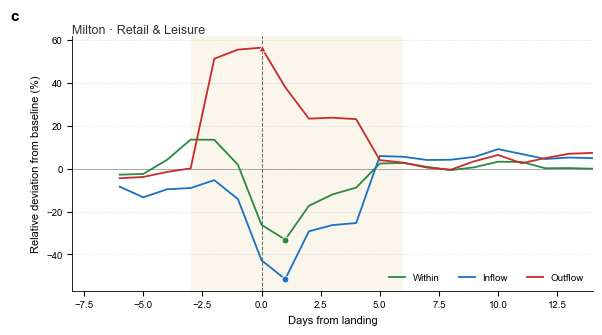

In [7]:
def panel_c_three_flows(ax):
    hkey = EXAMPLE['hurricane']
    cat  = EXAMPLE['category']
    landing = HURRICANES[hkey]['landing']

    win_lo, win_hi = -8, 14

    # Stack the three flow curves
    for flow in ['within', 'inflow', 'outflow']:
        df = load_relative_deviation(hkey, flow, cat)
        d  = df.copy()
        d['days_from_landing'] = (d.index - landing).days
        d = d[(d['days_from_landing'] >= win_lo) & (d['days_from_landing'] <= win_hi)]
        ax.plot(d['days_from_landing'], d['rel_dev'],
                color=FLOW_COLORS[flow], linewidth=1.3, label=FLOW_LABELS[flow])

        # Trough / peak marker from metrics summary
        row = METRICS[(METRICS['hurricane'] == hkey)
                      & (METRICS['flow_type'] == flow)
                      & (METRICS['category']  == cat)]
        if not row.empty:
            if flow in ('within', 'inflow') and pd.notna(row['drop_date'].iloc[0]):
                t = (pd.to_datetime(row['drop_date'].iloc[0]) - landing).days
                v = float(row['largest_drop'].iloc[0])
                ax.scatter([t], [v], s=24, color=FLOW_COLORS[flow],
                           edgecolor='white', linewidth=0.6, zorder=5)
            if flow == 'outflow' and pd.notna(row['increase_date'].iloc[0]):
                t = (pd.to_datetime(row['increase_date'].iloc[0]) - landing).days
                v = float(row['largest_increase'].iloc[0])
                ax.scatter([t], [v], s=24, color=FLOW_COLORS[flow],
                           edgecolor='white', linewidth=0.6, zorder=5,
                           marker='^')

    # Landing reference + zero baseline
    ax.axvline(0, color='#666666', linestyle='--', linewidth=0.7, zorder=1)
    ax.axhline(0, color='#888888', linestyle='-', linewidth=0.5, zorder=1)

    # Surge window shading
    ax.axvspan(SURGE_WINDOW[0], SURGE_WINDOW[1],
               facecolor='#f0e3c2', alpha=0.30, zorder=0)

    ax.set_xlim(win_lo, win_hi)
    ax.set_xlabel('Days from landing')
    ax.set_ylabel('Relative deviation from baseline (%)')
    ax.set_title(f"{HURRICANES[hkey]['label']} \u00b7 {cat}",
                 loc='left', fontsize=9, color='#333', pad=2)
    ax.legend(loc='lower right', frameon=False, fontsize=7,
              handlelength=1.6, ncol=3)
    ax.grid(axis='y', linestyle=':', color='#bbbbbb', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    ax.text(-0.12, 1.05, 'c', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_c, ax_c = plt.subplots(figsize=(6.0, 3.4))
panel_c_three_flows(ax_c)
fig_c.tight_layout()
save_panel(fig_c, 'figure3c_three_flows')
plt.show()

### Caption draft (for use when you assemble the combined Fig. 3)

**Fig. 3 | Flow-type decomposition: “recovery” depends on which network direction you measure.**
**(a)** Trend-based recovery time (Theil–Sen, days from landing) for within-region (green) and inflow (blue) trips across the six urban-functional categories, for Hurricane Helene (*n* = 271 counties) and Hurricane Milton (*n* = 21 counties). Inflow recovers more slowly than within-region for nearly every category, especially under Helene.
**(b)** Outflow relative deviation from the SARIMAX counterfactual baseline, expressed in percent and aligned to landing day for each category. The shaded yellow band marks the **−3 d → +6 d** evacuation window used to extract the largest positive deviation (`largest_increase`, marked by circles). Helene exhibits an *outflow drop* (infrastructure damage prevented departure) while Milton shows a pronounced *pre-landfall surge* (forecasted evacuation), with the strongest categories peaking at ≃+30 → +50 %.
**(c)** Worked example for the selected category showing within (green), inflow (blue), and outflow (red) relative deviations on a single time axis. The trough markers (filled circles) lie 1–2 days after landing for within and inflow, while the outflow peak (triangle) precedes landing.

*Adjust the example category/hurricane via the `EXAMPLE` dict in the configuration cell, then re-run the panel-(c) cell.*